Github: https://github.com/alexsong-lab/SML_group_project

# Beyond the Hype: Uncovering the True Shape of Washington's Electric Vehicle Landscape

By Alex Song, Gurpreet Kaur, and Naomi Le Mouel, students in the Seattle University Master of Science in Data Science (MSDS) program

## 1.Introduction
### If You Only Look at EV Counts, You Miss the Real Story

Open almost any report on electric vehicles in Washington State, and one county immediately dominates the conversation: King County.

King County has the most EVs, the most chargers, and some of the highest adoption rates in the state. Looking only at raw totals, it is easy to conclude that Washington's EV transition is simply a story of large urban counties leading the way while rural counties struggle to keep up.

**But what if that story is incomplete?**\
What if population size is drowning out the more interesting patterns? What if raw counts are masking deeper structural differences in how electric vehicles are actually adopted and supported across the state?

Some counties may have relatively few EVs but surprisingly strong charging infrastructure. Others may have rapidly modernized fleets despite smaller markets. And a few may be operating under entirely different conditions.

[**Washington ranks third in the nation**](https://wsdot.wa.gov/about/data/gray-notebook/gnbhome/environment/electricvehicles/electricvehicles.htm) in EV market share, making it one of the most EV-friendly states in the country. Yet statewide statistics hide substantial variation between counties. Understanding that variation is important for identifying where EV adoption is thriving, where infrastructure may be lagging, and where different policy approaches may be needed.

The primary reaserch question for this project was this:

What underlying EV adoption patterns exist across Washington's 39 counties once we remove the population-driven "King County Effect"_?_

To answer this question, we applied several unsupervised learning techniques: Principal Component Analysis (PCA), Singular Value Decomposition (SVD), K-Means Clustering, Hierarchical Clustering.

Our dataset combines county-level information on EV registrations, charging infrastructure, vehicle characteristics, and socioeconomic indicators for all 39 Washington counties. Variables include EV counts, charger counts, BEV and PHEV shares, average electric range, average vehicle age, average model year, charger density measures, and median income.

Rather than predicting an outcome, our goal was to uncover hidden patterns and determine whether counties naturally group together based on their EV ecosystem characteristics.

Note: Our analysis uses four primary data sources: Washington State's EV registration dataset, the statewide public EV charging station dataset, county median household income estimates from the Washington Office of Financial Management, and county profile data from the Municipal Research and Services Center (MRSC).


## 2. Theoretical Background
**2.1 Principal Component Analysis (PCA)**\
When you have a bunch of variables that all move together - like EV counts, charger counts, and BEV shares - PCA is a great way to simplify the picture. The idea is to rotate the data into a new set of axes (called _principal components_) that capture the biggest patterns of variation.

The first component explains the most variation, the second explains the next most, and so on. Each component comes with:
- **Loadings**, which tell you which variables define the component
- **Scores**, which tell you where each county sits along that component

In practice, we look at scree plots and variance‑explained charts to decide how many components are worth keeping. PCA is powerful when variables are correlated, but interpreting components can be tricky because each one blends multiple variables together.

**2.2 Singular Value Decomposition (SVD)**\
SVD is the mathematical engine under the hood of PCA. If you take your data matrix (X) and decompose it into: \[ X = U ∑ V\* \]

You get three pieces:
- **U** , which describes how counties relate to hidden patterns
- **∑** , which tells you how strong those patterns are
- **V\*** , which shows how variables contribute to each pattern

As described in *An Introduction to Statistical Learning with Applications in Python* (ISLP) ([see reference](#islp-ref)), PCA  loadings come directly from the (V\*) matrix, and PCA scores come from (U∑). That's why PCA and SVD should agree - they're looking at the same geometry from two angles. SVD can also be used for matrix completion when the underlying data matrix is approximately low‑rank and the missing entries are not systematically biased, but its success depends on the structure of the data rather than the amount of missingness alone.

**2.3 How PCA arises from SVD.**\
One useful way to think about PCA is that it simply repackages the SVD. The principal component *loadings* come directly from the right singular vectors (the columns of \( V^\* \)), and the PCA *scores* are given by \( U \Sigma \). In other words, PCA is just SVD applied to the standardized data matrix, which is why the two methods should tell the same geometric story — and in our case, they did.

**2.4 K**‑**Means Clustering**\
K‑Means is one of the simplest ways to group similar counties together. You pick a number of clusters (k), and the algorithm keeps shuffling counties around until each one is assigned to the nearest cluster center. Because K‑Means can get stuck in local optima, ISLP ([see reference](#islp-ref)) recommends running it multiple times with different random starts. We typically use elbow plots and within‑cluster variation to decide on a good value of (k).

K‑Means works best when clusters are compact and well separated - which is why we also checked our results with hierarchical clustering.

**2.5 Hierarchical Clustering**\
Hierarchical clustering takes a more flexible approach. Instead of choosing the number of clusters upfront, it builds a dendrogram - a tree that shows how counties merge together step by step.

You can "cut" the tree at different heights to get different numbers of clusters. This makes hierarchical clustering great for exploratory work because you can see structure at multiple levels. The catch is that results depend heavily on the linkage method.

**2.6 Linkage Methods**
Linkage methods define how distances between clusters are measured:
- **Single linkage**: looks at the closest pair of points (can create long chains)
- **Complete linkage**: looks at the farthest pair (creates tight, compact clusters)
- **Average linkage**: averages all pairwise distances (a middle ground)
- **Ward linkage**: merges clusters that increase within‑cluster variance the least

Ward linkage often produces the cleanest, most interpretable structure - which is why it's commonly paired with PCA‑based clustering and why we used it in our analysis.


## 3. Methodology
**3.1 Data Collection and Variable Selection**\
Electric vehicle registration, charger location, city/county lookup, and county income datasets were cleaned and merged to create a county level dataset for analysis. Across all files, column names were standardized, extra spaces were removed, and formatting was made consistent.

For the EV registration dataset, placeholder zeros in electric_range and sale_price were converted to NaN because they represented missing rather than true zero values. County, city, and state labels were standardized, only Washington State records were kept, unrealistic model years were removed, duplicate vehicle records were dropped, and a vehicle_age variable was created using model year.

The charger location dataset was cleaned by standardizing labels and dates and removing nonessential geographic, address, ID, and descriptive fields to focus on county level analysis. Charger counts and duplicate records were checked before aggregation. To assign charger stations to counties, the city/county lookup dataset was cleaned and merged using city names. For cities that appeared in multiple counties, we manually resolved the conflicts by cross‑checking MRSC’s county profile database and verifying geographic context. In a few cases, the same city name legitimately existed in more than one county and in those situations, we used charger address details and nearby landmarks to assign the correct county. Any remaining unmatched cities were assigned based on the most consistent county association across datasets. These steps ensured that every charger location had a valid county assignment. These steps reduced missing charger county assignments to zero.

County income data were simplified by keeping county and 2025 median income values, standardizing county names, and converting income values to numeric format before merging.EV registration data were then aggregated to the county level to create total EV count, BEV count, PHEV count, average model year, average electric range, average vehicle age, percent BEV, percent PHEV, and the BEV-to-PHEV ratio.Population based variables were evaluated but excluded because the available population file appeared to contain city level rather than complete county populations, producing unrealistic EV-per-capita estimates.

**3.2 A Quick Note on Matrix Competion**\
Matrix completion was explored for missing electric_range values. However, roughly 44% of values would have required imputation, and the completed values reduced realistic county variation. Because county aggregation using observed means still produced complete county averages without missing data, preserving observed information was considered more reliable. Matrix completion was therefore evaluated and documented but not used to alter the final dataset.

Matrix completion doesn’t actually require extremely high missingness. What matters is whether the underlying data matrix is close to low‑rank and whether the missing entries are not systematically biased. When those conditions hold, completion can recover meaningful latent structure even with moderate missingness. In our case, though, the completed electric‑range values collapsed real county‑level variation, so we chose to preserve the observed means instead.

<div style="text-align:left">

1. Missingness Summary
   
| Description | Value |
| --- | --- |
| Missing county avg_electric_range before matrix completion | 0 |
| Missing county avg_electric_range after matrix completion | 0 |

<br>

2. Observed vs Completed avg_electric_range

| county | avg_electric_range_observed | avg_electric_range |
| --- | --- | --- |
| ADAMS | 111.452722 | 111.452722 |
| ASOTIN | 95.222698 | 95.222698 |
| BENTON | 108.205155 | 108.205155 |
| CHELAN | 125.745458 | 125.745458 |
| CLALLAM | 98.694111 | 98.694111 |
   
</div>

Although matrix completion produced a fully populated electric‑range matrix, the imputed values showed noticeably reduced variation across counties. In practice, the completed matrix pulled county averages toward a common low‑rank structure, flattening meaningful differences that were present in the observed data. Because this behavior suggested that the low‑rank assumption was not appropriate for electric‑range values, we documented the results but did not incorporate matrix completion into the final pipeline.

**3.3 Addressing the "King County Effect"**\
The first thing we noticed during exploratory analysis was how dramatically county sizes differed. King County's EV ecosystem is enormous compared to many rural counties. Snohomish and Pierce also contain far more EVs and chargers than most of the state. If we applied PCA or clustering directly to the raw numbers, the algorithms would mostly learn one thing: **Big counties are big,** and that isn't very interesting.

To reduce this effect, we applied two preprocessing steps:\
    **- Step 1** **-** **Log Transformations:** Count-based variables such as EV counts and charger counts were heavily right-skewed. Applying logarithmic transformations compressed extreme values and reduced the influence of large outliers.
    **- Step 2 - Standardization:** Variables were standardized so that every feature contributed equally to the analysis. Without standardization, variables measured on larger scales would dominate the results.

This ensured that variables measured on different scales contributed equally to PCA and clustering. Once these steps were complete, we were finally ready to let the data speak for itself.

**3.4 Principal Component Analysis:**\
PCA was performed on the standardized feature matrix. We examined-scree plots, variance explained, component loadings, PCA score plots-to determine how many components should be retained and how they should be interpreted.

**3.5 Singular Value Decomposition:**\
A manual SVD was performed on the standardized matrix. The resulting (U) and (V\*) matrices were compared with PCA scores and loadings to validate the decomposition.

**3.6 Clustering:**\
Clustering was performed using PCA-transformed data.

**3.7 K-Means:**
We evaluated multiple cluster solutions, including k = 3 and k = 4 using elbow plots and interpretability.

**3.8 Hierarchical Clustering:**\
We compared: single linkage, complete linkage, average linkage, ward linkage, and evaluated dendrogram structures for each method.

**3.9 How clustering was actually performed.**\
All clustering was done on the PCA‑transformed, standardized feature matrix using Euclidean distance, which is the default for both K‑Means and hierarchical clustering. K‑Means was run with 20 random initializations to avoid local optima, and we evaluated solutions from \(k = 2\) through \(k = 10\) using inertia and silhouette scores. For hierarchical clustering, we computed pairwise Euclidean distances and applied four linkage methods (single, complete, average, and Ward). Ward linkage is designed to minimize within‑cluster variance, which makes it naturally compatible with Euclidean distance — and explains why it most closely matched the K‑Means solution.

A natural question is whether correlation distance would have been a better choice than Euclidean distance, especially given the large differences in county size. In our case, correlation distance would remove magnitude information entirely and focus only on relative patterns. Because we already applied log transformations and standardization, the PCA‑transformed features no longer carry raw size effects, and Euclidean distance captures meaningful differences in EV ecosystem scale without letting county size dominate. For this reason, Euclidean distance was the more appropriate choice for our clustering workflow.


## 4. Result
### 4.1 PCA Results

**Variance Explained**

| **Index** | **PC** | **Explained Variance (%)** | **Cumulative Variance (%)** |
| --- | --- | --- | --- |
| 0 | PC1 | 49.30 | 49.30 |
| 1 | PC2 | 18.98 | 68.28 |
| 2 | PC3 | 12.69 | 80.97 |
| 3 | PC4 | 6.83 | 87.80 |
| 4 | PC5 | 5.27 | 93.07 |
| 5 | PC6 | 3.70 | 96.77 |
| 6 | PC7 | 1.52 | 98.29 |

<br>

**Scree Plot**

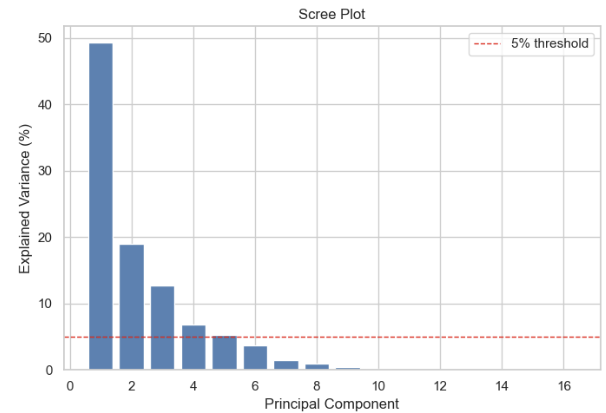\
Figure 1. Scree Plot

<br>

**PCA Loadings (First 5 PCs, First 8 Features)**

| **Feature** | **PC1** | **PC2** | **PC3** | **PC4** | **PC5** |
| --- | --- | --- | --- | --- | --- |
| avg_model_year | 0.1403 | 0.3851 | 0.2436 | -0.4877 | -0.0195 |
| avg_electric_range | 0.1843 | 0.4086 | -0.2508 | 0.1695 | -0.0234 |
| avg_vehicle_age | -0.1403 | -0.3851 | -0.2436 | 0.4877 | 0.0195 |
| percent_BEV | 0.2771 | 0.2882 | -0.1928 | 0.1454 | -0.1000 |
| percent_PHEV | -0.2767 | -0.2885 | 0.1934 | -0.1456 | 0.1017 |
| BEV_to_PHEV_ratio | 0.2652 | 0.2397 | -0.2472 | 0.2982 | 0.0160 |
| median_income_2025 | 0.2838 | -0.1946 | -0.1545 | -0.0078 | -0.1080 |
| fast_charger_share | 0.0355 | 0.0746 | 0.5393 | 0.4594 | -0.3121 |

<br>

**PCA Scores (First 10 Counties)**

| **Index** | **County** | **PC1** | **PC2** | **PC3** | **PC4** | **PC5** |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | ADAMS | -1.8334 | 2.4016 | 2.1386 | 1.9329 | -0.4460 |
| 1 | ASOTIN | -3.1263 | 0.0520 | -0.8448 | -0.5159 | 0.1161 |
| 2 | BENTON | 1.0864 | -0.8077 | 0.2285 | -0.3395 | -0.9504 |
| 3 | CHELAN | 2.8341 | 1.7620 | -0.0077 | 0.9521 | 1.8228 |
| 4 | CLALLAM | 0.0074 | -1.4670 | 0.7734 | 0.9852 | -0.0188 |
| 5 | CLARK | 3.2603 | -1.1005 | 0.5343 | -0.6238 | -1.1659 |
| 6 | COLUMBIA | -1.2714 | 4.3674 | -0.5190 | 1.9448 | 1.6017 |
| 7 | COWLITZ | 0.3578 | 0.4187 | 1.1873 | 0.4135 | -1.0861 |
| 8 | DOUGLAS | -0.3197 | 1.2472 | -1.4279 | 0.1007 | -0.6466 |
| 9 | FERRY | -1.9944 | 3.6320 | -3.1560 | 0.0515 | -0.9958 |

<br>

**PC1 vs PC2**

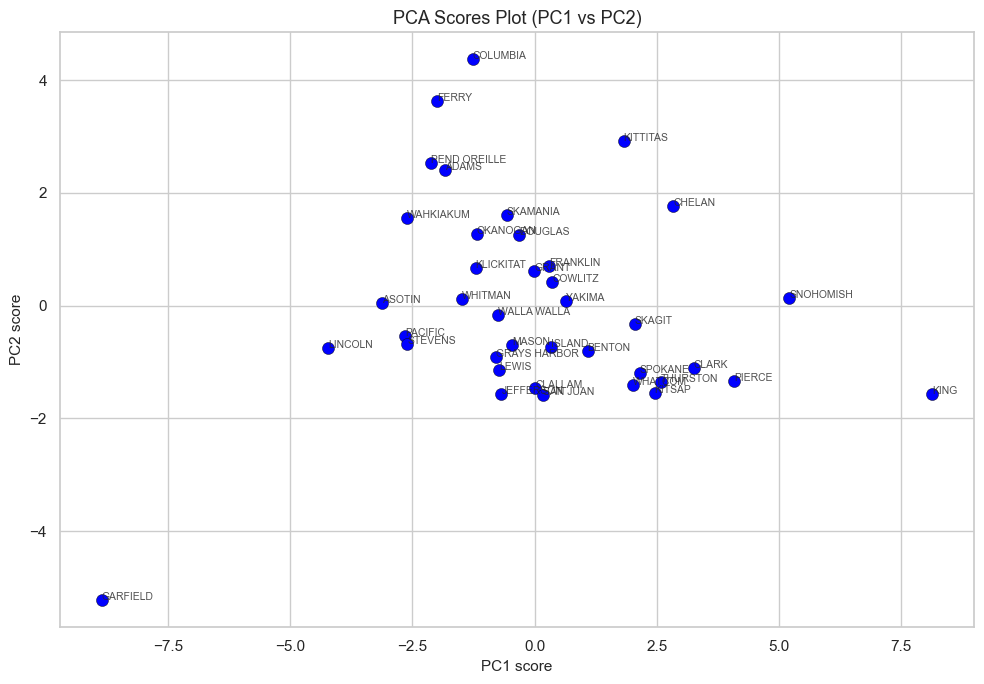\
Figure 2. PCA Projection (PC1 vs PC2)

<br>

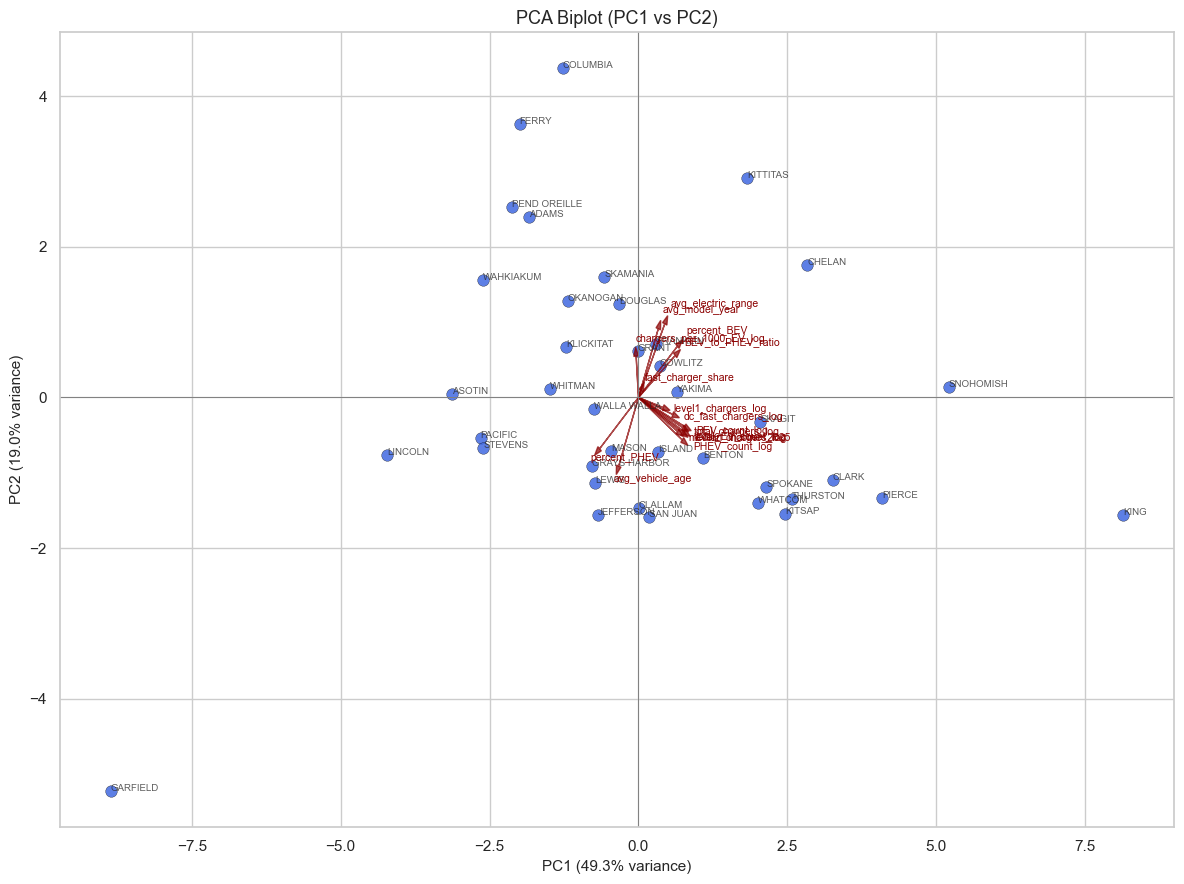\
Figure 3. PCA Biplot

<br>

### 4.2 SVD Results
**Singular Values**

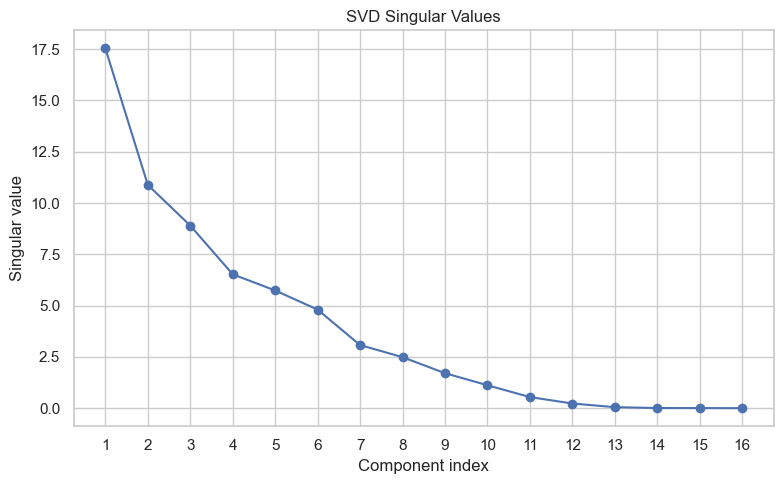

<br>

**U Matrix (First 10 Counties, First 5 Columns)**

| **County** | **U1** | **U2** | **U3** | **U4** | **U5** |
| --- | --- | --- | --- | --- | --- |
| ADAMS | 0.104535 | 0.220673 | 0.240299 | 0.296177 | -0.077748 |
| ASOTIN | 0.178249 | 0.004780 | -0.094924 | -0.079056 | 0.020230 |
| BENTON | -0.061944 | -0.074216 | 0.025676 | -0.052026 | -0.165666 |
| CHELAN | -0.161585 | 0.161901 | -0.000863 | 0.145882 | 0.317742 |
| CLALLAM | -0.000421 | -0.134795 | 0.086903 | 0.150956 | -0.003273 |
| CLARK | -0.185888 | -0.101119 | 0.060035 | -0.095582 | -0.203226 |
| COLUMBIA | 0.072492 | 0.401303 | -0.058321 | 0.298001 | 0.279189 |
| COWLITZ | -0.020397 | 0.038473 | 0.133411 | 0.063361 | -0.189312 |
| DOUGLAS | 0.018230 | 0.114603 | -0.160449 | 0.015429 | -0.112715 |
| FERRY | 0.113714 | 0.333728 | -0.354622 | 0.007884 | -0.173584 |

<br>

**PCA-SVD Alignment**

| **Comparison** | **Correlation** |
| --- | --- |
| PC1 vs V1 | 1.000 |
| PC2 vs V2 | 1.000 |

<br>

### 4.3 K-Means Results
**Elbow Plot**

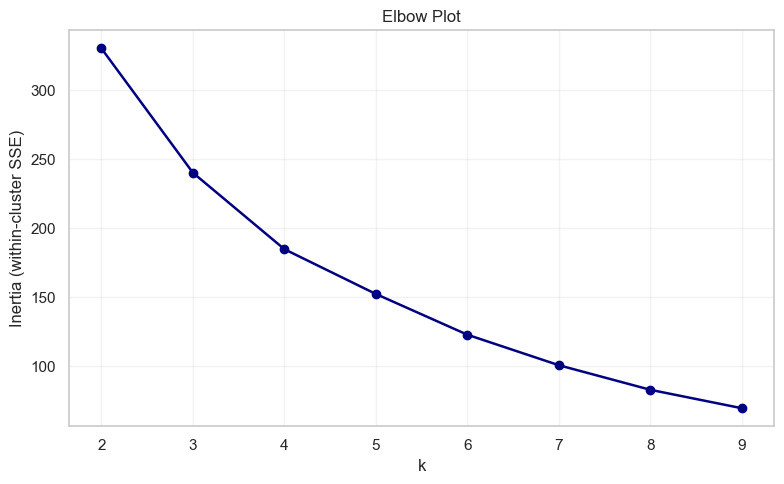

<br>

**Silhouette Plot**

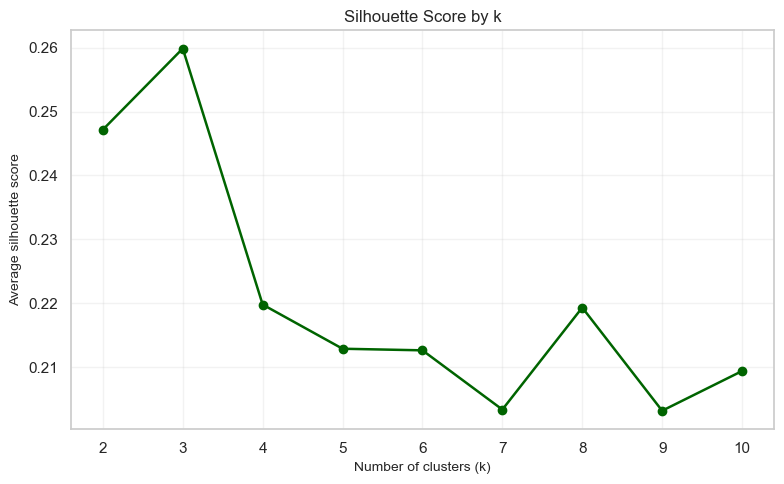

<br>

**K-Mean diagnostics Table**

| **Index** | **k** | **Inertia** | **Silhouette** |
| --- | --- | --- | --- |
| 0 | 2 | 447.478669 | 0.247166 |
| 1 | 3 | 351.358202 | 0.259849 |
| 2 | 4 | 296.606159 | 0.219822 |
| 3 | 5 | 253.642350 | 0.212920 |
| 4 | 6 | 213.852169 | 0.212669 |
| 5 | 7 | 183.167415 | 0.203409 |
| 6 | 8 | 162.851863 | 0.219357 |
| 7 | 9 | 139.973530 | 0.203228 |
| 8 | 10 | 123.376091 | 0.209431 |

<br>

**Final K-Mean Cluster Assignment**

| **Cluster** | **Counties** |
| --- | --- |
| 0 | BENTON, CHELAN, CLARK, KING, KITSAP, PIERCE, SKAGIT, SNOHOMISH, SPOKANE, THURSTON, WHATCOM |
| 1 | ADAMS, CLALLAM, COLUMBIA, COWLITZ, FRANKLIN, GRANT, GRAYS HARBOR, KITTITAS, LEWIS, LINCOLN, YAKIMA |
| 2 | ASOTIN, DOUGLAS, FERRY, ISLAND, JEFFERSON, KLICKITAT, MASON, OKANOGAN, PACIFIC, PEND OREILLE, SAN JUAN, SKAMANIA, STEVENS, WALLA WALLA, WAHKIAKUM, WHITMAN |
| 3 | GARFIELD |

<br>

**Cluster Centroid (Scaled Feature Space — Part 1)**

| Cluster | avg_model_year | avg_electric_range | avg_vehicle_age | percent_BEV | percent_PHEV | BEV_to_PHEV_ratio | median_income_2025 | fast_charger_share |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| cluster_0 | 0.214 | 0.282 | -0.214 | 0.616 | -0.614 | 0.710 | 1.213 | 0.004 |
| cluster_1 | 0.146 | -0.026 | -0.146 | -0.095 | 0.096 | -0.152 | -0.551 | 1.230 |
| cluster_2 | -0.016 | 0.015 | 0.016 | -0.094 | 0.092 | -0.230 | -0.403 | -0.796 |
| cluster_3 | -3.707 | -3.047 | 3.707 | -4.225 | 4.223 | -2.460 | -0.847 | -0.849 |

Table A — Vehicle + Adoption Features

<br>

**Cluster Centroid (Scaled Feature Space — Part 2)**

| Cluster | total_EV_count_log | BEV_count_log | PHEV_count_log | total_chargers_log | level1_chargers_log | level2_chargers_log | dc_fast_chargers_log | chargers_per_1000_EV_log |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| cluster_0 | 1.161 | 1.154 | 1.145 | 1.158 | 0.690 | 1.184 | 1.046 | -0.343 |
| cluster_1 | -0.300 | -0.293 | -0.301 | 0.020 | -0.354 | -0.368 | 0.520 | 0.911 |
| cluster_2 | -0.434 | -0.420 | -0.439 | -0.679 | -0.209 | -0.447 | -1.008 | -0.255 |
| cluster_3 | -2.525 | -2.750 | -2.256 | -2.091 | -0.354 | -1.817 | -1.099 | -2.165 |

Table B — Charger + Log‑Transformed Features

<br>

**K-Means Cluster on PCA Plane (k=3)**

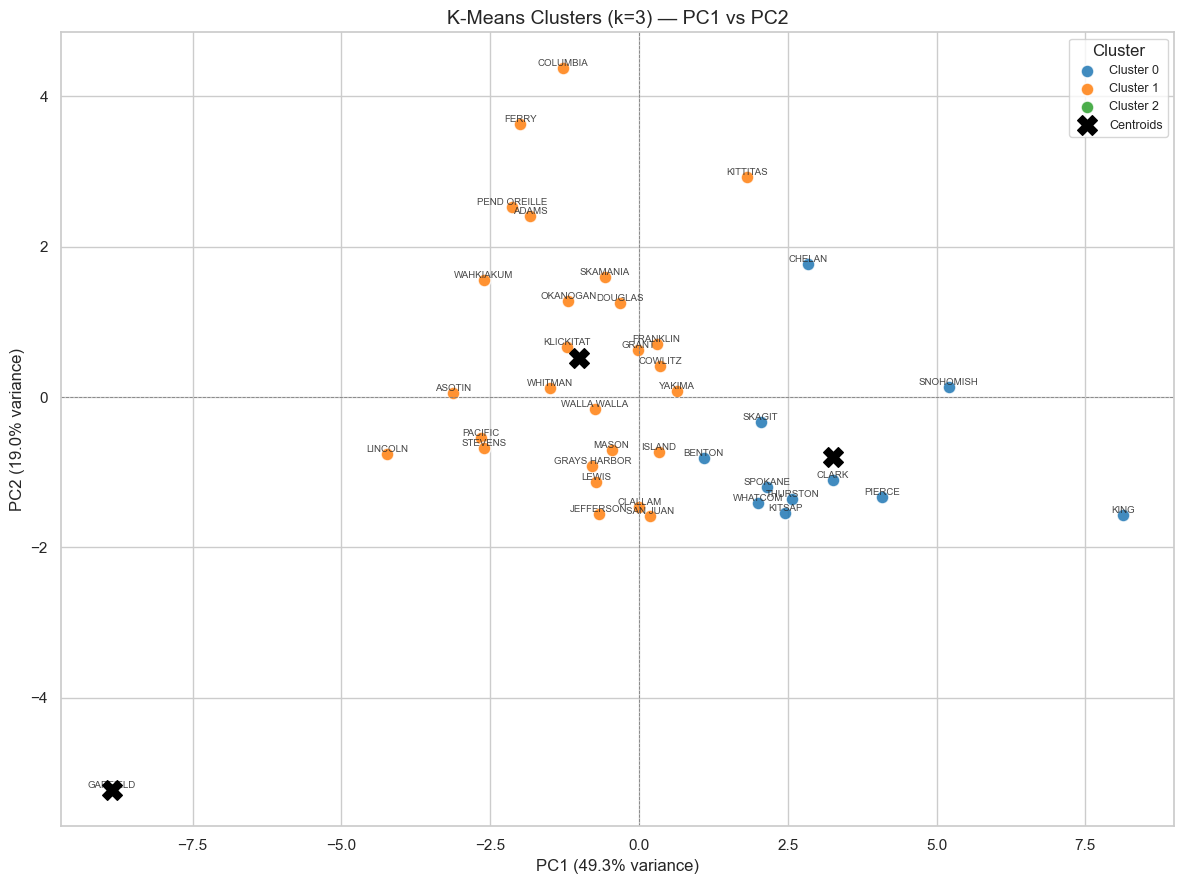\
Figure 4. K‑Means Clusters on PCA Plane

<br>

### 4.4 Hierarchical Clustering Result
**Dendrograms (4 Linkage Methods)**

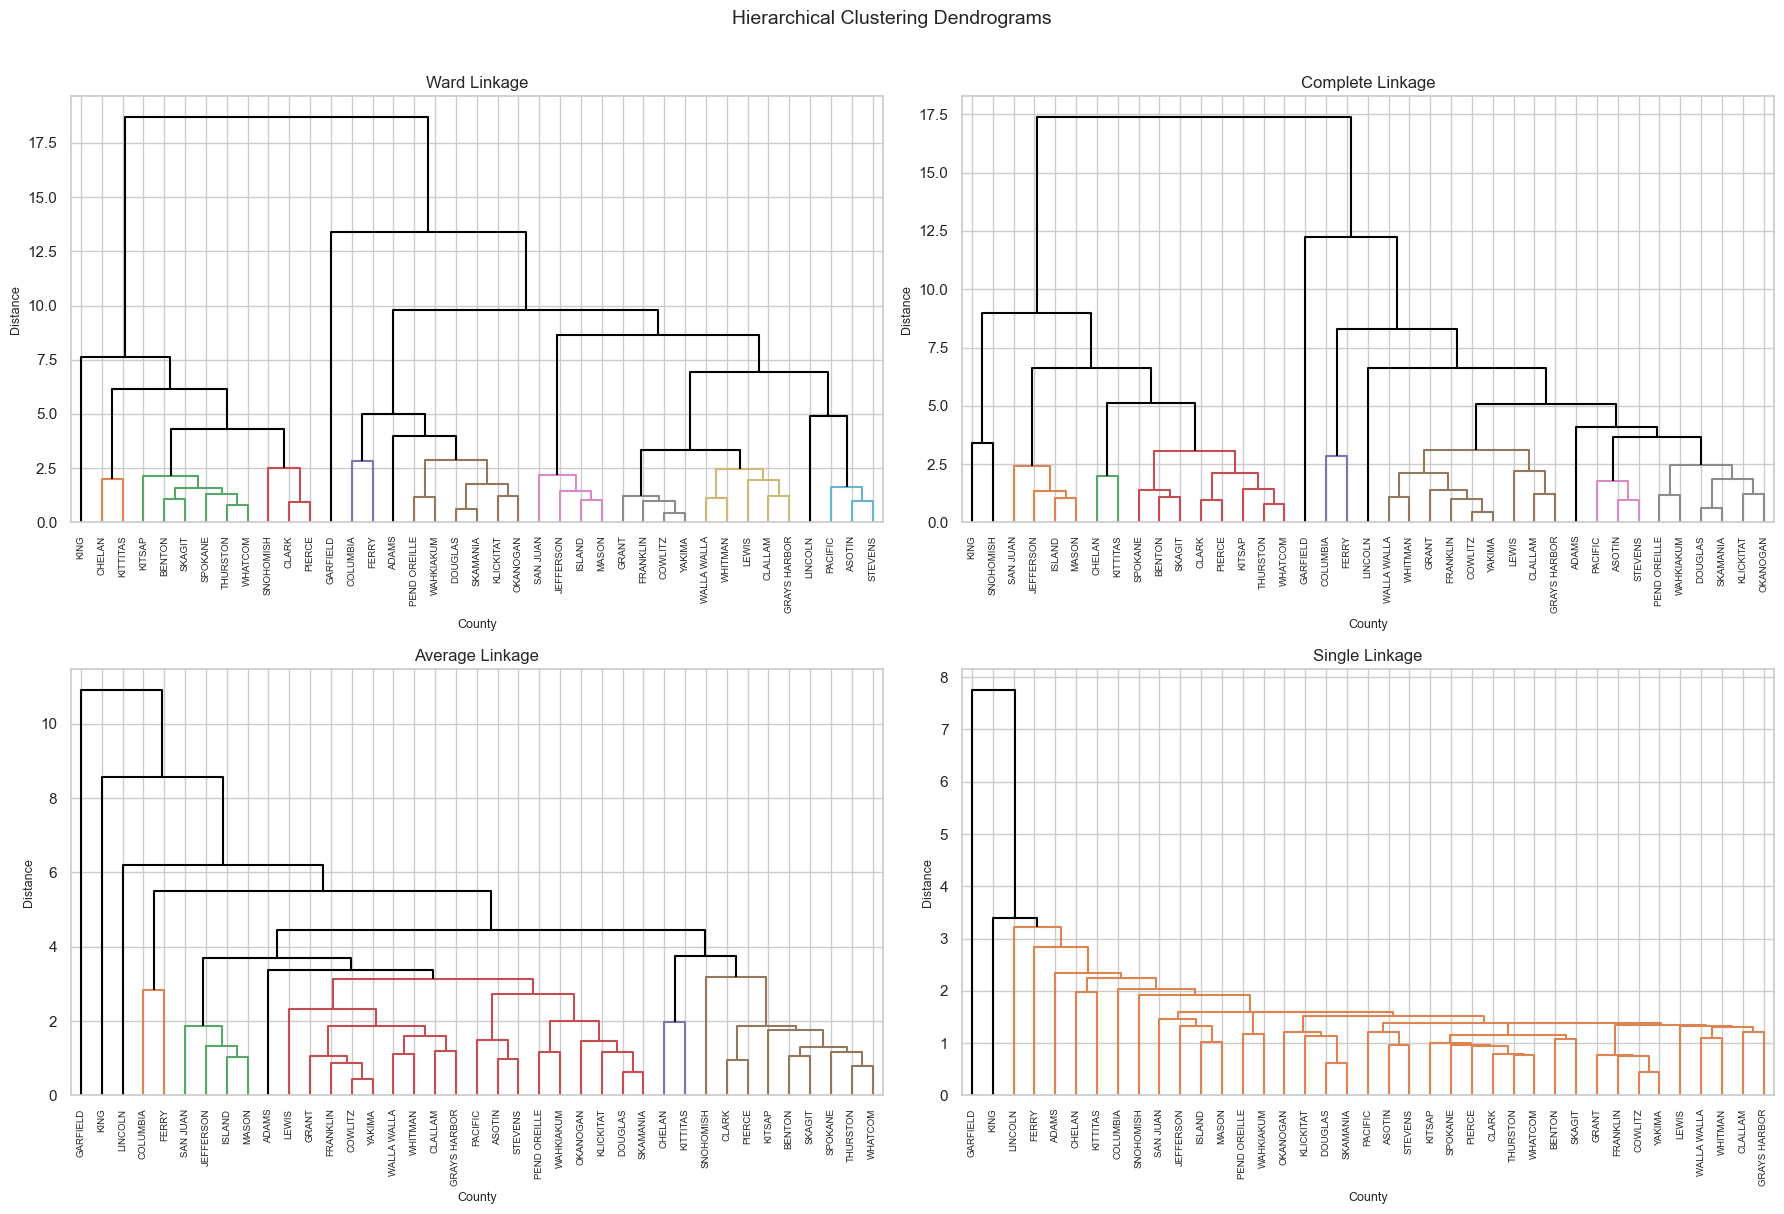

<br>

**Cut-Tree Assignment**

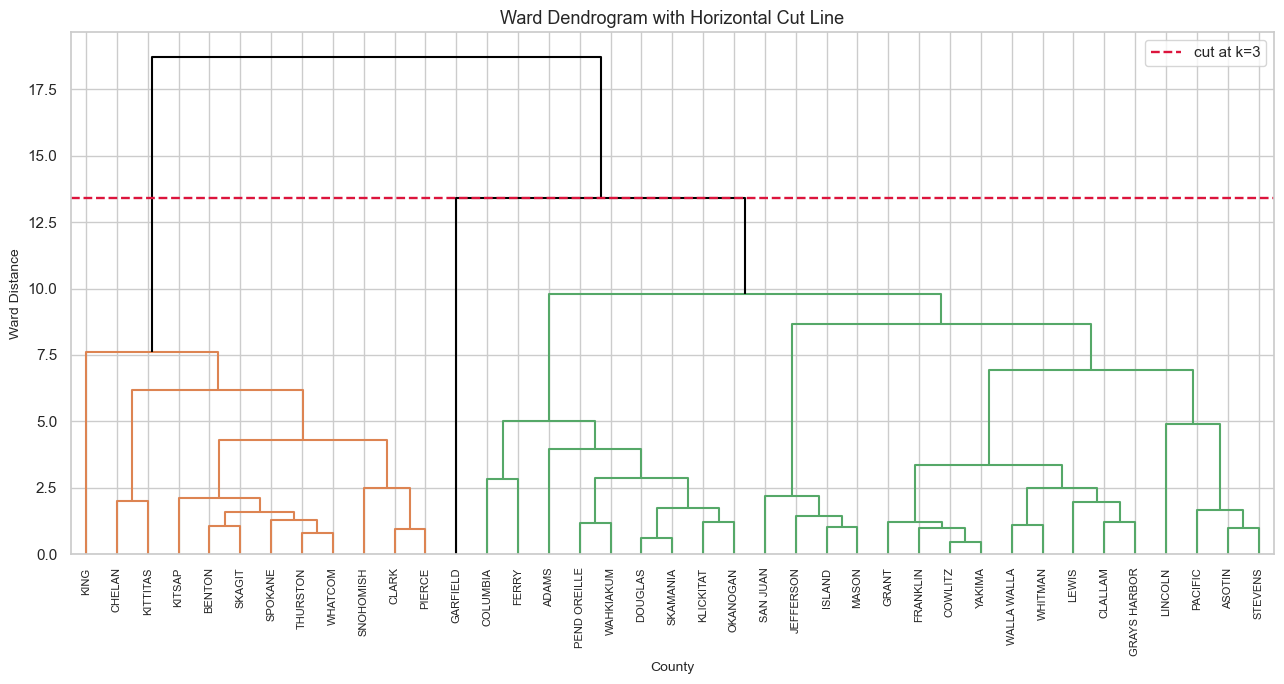

**A note on distance‑based limitations.**  
Because both K‑Means and hierarchical clustering rely on Euclidean distance, they implicitly assume that clusters are roughly spherical in the transformed feature space. This makes them sensitive to elongated or irregular cluster shapes. It also explains why single and average linkage tend to “chain” counties together under Euclidean distance — exactly what we observed. Ward linkage avoids this by explicitly minimizing within‑cluster variance, which is why it produced the cleanest and most stable structure in our results.


## 5. Discussion

One thing that became clear throughout this project is that EV adoption in Washington is much more complicated than simply looking at which counties have the most electric vehicles. At the start of the analysis, counties such as King, Snohomish, and Pierce dominated nearly every count-based variable. Without additional preprocessing, most machine learning methods would have focused almost entirely on county size rather than on meaningful differences in EV adoption patterns.

After applying log transformations and standardization, a much more interesting picture emerged. PCA showed that most of the variation across Washington's counties could be summarized using just three dimensions. Rather than representing the same information repeatedly, these components captured different aspects of the EV landscape: overall adoption scale, fleet modernization, and charging infrastructure intensity. The fact that three components explained more than 80% of the total variance suggests that the original sixteen variables contained a large amount of overlapping information.

It was also encouraging to see how consistently the different methods agreed with one another. PCA and SVD produced essentially identical results, and both pointed to the same underlying dimensions. Similarly, K-Means and hierarchical clustering identified nearly the same county groupings. When several independent methods arrive at the same conclusions, it increases confidence that the patterns are real and not simply artifacts of a particular algorithm.

Perhaps the most interesting finding was Garfield County. Before starting the project, we expected King County to stand out because of its large EV market. Instead, Garfield became the most unusual county in the analysis. It consistently appeared as an outlier in PCA plots, singular vector analysis, K-Means clustering, and hierarchical clustering. This suggests that Garfield is not just a smaller version of other rural counties. Its EV adoption and charging infrastructure profile appears fundamentally different from the rest of the state.

The clustering results also highlight that Washington's counties cannot be treated as a single group. Urban counties tend to have large EV ecosystems and extensive charging infrastructure, while many rural counties share lower adoption levels but different infrastructure characteristics. These differences suggest that counties may face different challenges as EV adoption continues to grow. Some areas may require additional charging capacity to keep up with demand, while others may benefit more from policies that encourage adoption in the first place.

There are several limitations to this analysis. First, the study was performed at the county level, which reduces the amount of available data to only 39 observations. Important differences within counties may therefore be hidden. Second, population-based variables could not be included because the available population dataset was not suitable for county-level calculations. Finally, a large portion of the electric range data contained missing values. Although matrix completion was explored, the imputed values appeared to reduce natural variation, so the final analysis relied on observed county-level averages instead.

Despite these limitations, the results were remarkably consistent across all methods. The agreement between PCA, SVD, K-Means, and hierarchical clustering suggests that the identified patterns represent meaningful differences in how EV adoption is developing across Washington State. Rather than a single statewide story, the results point to several distinct EV adoption pathways that vary across counties.


## 6. Conclusion

This project demonstrates that Washington State's EV landscape is shaped by more than simple population differences. By combining data cleaning, feature engineering, dimensionality reduction, and clustering techniques, we identified three major dimensions of EV adoption-scale, modernization, and charging intensity-that together explain over 81% of the variation across counties.

The analysis revealed three broad EV adoption archetypes: urban leaders with extensive EV ecosystems and infrastructure, rural baseline counties with moderate adoption patterns, and Garfield County as a persistent structural outlier. Importantly, these patterns were consistently identified across multiple analytical approaches, including PCA, SVD, K-Means clustering, and hierarchical clustering, providing strong validation of the results.

From a policy perspective, the findings suggest that a single statewide strategy may not be effective for accelerating EV adoption. Urban counties face challenges related to infrastructure capacity and demand management, while rural counties may require targeted support to overcome adoption barriers and expand charging access. Unique cases such as Garfield County may require specialized local solutions that differ substantially from broader statewide initiatives.

More broadly, this study demonstrates the value of unsupervised learning methods for uncovering hidden patterns in complex transportation datasets. As EV adoption continues to grow, understanding these regional differences can help policymakers, utilities, and transportation planners allocate resources more effectively and design programs that better reflect the diverse needs of Washington communities. The methods used in this project could also be extended to other states or emerging transportation technologies to support future data-driven policy decisions.

### References

[1] Electric Vehicle Title and Registration Activity - Washington State Department of Licensing  
<https://data.wa.gov/Transportation/Electric-Vehicle-Title-and-Registration-Activity/rpr4-cgyd/about_data>

<a name="islp-ref"></a>
[2] James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An Introduction to Statistical Learning: With Applications in Python*. Springer.

[3] Public EV Charging Stations - WA GeoServices  
<https://geo.wa.gov/datasets/wa-geoservices::public-ev-charging-stations/about>  
**Note:** If the link cannot be accessed due to the `::` characters, visit https://geo.wa.gov/ or https://ev-map-wsdot.hub.arcgis.com/ and search for “Public EV Charging Stations” in the WA GeoServices catalog.

[4] Median Household Income Estimates - Washington Office of Financial Management  
<https://ofm.wa.gov/data-research/economy/median-household-income-estimates/>

[5] County Profiles (City–County Lookup) - Municipal Research and Services Center (MRSC)  
<https://mrsc.org/research-tools/county-profiles>
